# Toy Sentiment Task: Short Sentences

Train a tiny MLP to classify short synthetic sentences as negative (0) or positive (1).
The sentences and labels are written directly below; no dataset download or LLM API is needed.
Run the entire notebook to train, evaluate, inspect activations, and ablate neurons.


In [1]:
import re

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(42)


### Get the Toy Dataset

Use 24 short training sentences and 6 held-out validation sentences, balanced between
positive (1) and negative (0). These are synthetic, manually labeled examples with
obvious sentiment words. Labels are provided explicitly rather than calculated by counting
positive and negative words.

Represent each sentence with bag-of-words counts. Build the vocabulary from training
sentences only; lowercase text and ignore punctuation. Unknown words are ignored.
Word order is discarded, so this simple model does not handle negation or sarcasm.
Validation sentences use familiar words in different sentences. This is a tiny demonstration,
not a measure of real-world sentiment understanding.


In [2]:
# Synthetic sentences with explicit labels: 0 = negative, 1 = positive.
train_data = [
    ("The movie was good.", 1),
    ("The movie was bad.", 0),
    ("The book was great.", 1),
    ("The book was awful.", 0),
    ("The meal was excellent.", 1),
    ("The meal was terrible.", 0),
    ("The game was fun.", 1),
    ("The game was boring.", 0),
    ("The service was lovely.", 1),
    ("The service was poor.", 0),
    ("The music was wonderful.", 1),
    ("The music was disappointing.", 0),
    ("We had a good meal.", 1),
    ("We had a bad meal.", 0),
    ("It was a great game.", 1),
    ("It was an awful game.", 0),
    ("The service was excellent today.", 1),
    ("The service was terrible today.", 0),
    ("This book was fun.", 1),
    ("This book was boring.", 0),
    ("It was a lovely movie.", 1),
    ("It was a poor movie.", 0),
    ("We had wonderful music today.", 1),
    ("We had disappointing music today.", 0),
]
val_data = [
    ("This movie was great.", 1),
    ("This movie was awful.", 0),
    ("The book was excellent today.", 1),
    ("The book was terrible today.", 0),
    ("We had a lovely meal.", 1),
    ("We had a poor meal.", 0),
]
class_names = ["negative", "positive"]

def tokenize(text):
    return re.findall(r"[a-z]+", text.lower())

train_texts, train_labels = zip(*train_data)
val_texts, val_labels = zip(*val_data)
words = sorted({word for text in train_texts for word in tokenize(text)})
word_to_index = {word: index for index, word in enumerate(words)}

def encode_texts(texts):
    features = torch.zeros((len(texts), len(words)))
    for row, text in enumerate(texts):
        for word in tokenize(text):
            if word in word_to_index:
                features[row, word_to_index[word]] += 1
    return features

X_train = encode_texts(train_texts)
X_val = encode_texts(val_texts)
y_train = torch.tensor(train_labels, dtype=torch.long)
y_val = torch.tensor(val_labels, dtype=torch.long)

print(f"Training sentences: {len(train_data)}, validation sentences: {len(val_data)}")
print("Input columns:", words)
print("Example sentence:", train_texts[0])
print("Input vector:", X_train[0].tolist())
print("Label:", class_names[y_train[0].item()])


Training sentences: 24, validation sentences: 6
Input columns: ['a', 'an', 'awful', 'bad', 'book', 'boring', 'disappointing', 'excellent', 'fun', 'game', 'good', 'great', 'had', 'it', 'lovely', 'meal', 'movie', 'music', 'poor', 'service', 'terrible', 'the', 'this', 'today', 'was', 'we', 'wonderful']
Example sentence: The movie was good.
Input vector: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0]
Label: positive


### Build and Train a Tiny MLP

The network has one input per vocabulary word, four hidden neurons, and two output
scores: `[negative, positive]`. Train for 100 epochs using cross-entropy loss,
then check accuracy on held-out sentences.


In [3]:
class SentimentMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(len(words), 4)
        self.fc2 = nn.Linear(4, 2)

    def forward(self, x):
        hidden = F.relu(self.fc1(x))
        return self.fc2(hidden), hidden

model = SentimentMLP()
optimizer = torch.optim.Adam(model.parameters(), lr=0.05)
criterion = nn.CrossEntropyLoss()

losses = []
for epoch in range(100):
    logits, _ = model(X_train)
    loss = criterion(logits, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

print(model)
print(f"Final training loss: {losses[-1]:.4f}")

model.eval()
with torch.no_grad():
    val_logits, _ = model(X_val)
    val_predictions = val_logits.argmax(dim=1)
    val_accuracy = (val_predictions == y_val).float().mean().item()
print(f"Validation accuracy: {val_accuracy:.0%} ({len(val_data)} held-out sentences)")


SentimentMLP(
  (fc1): Linear(in_features=27, out_features=4, bias=True)
  (fc2): Linear(in_features=4, out_features=2, bias=True)
)
Final training loss: 0.0000
Validation accuracy: 100% (6 held-out sentences)


### Input and Output Examples

| Sentence | Expected label |
| --- | --- |
| This movie was great. | 1 (positive) |
| This movie was awful. | 0 (negative) |
| We had a lovely meal. | 1 (positive) |
| We had a poor meal. | 0 (negative) |

The input vector counts every vocabulary word, including neutral words such as
`movie` and `was`. Its positions follow the printed `Input columns` list.
The model outputs two scores; `argmax` selects label 0 or 1.
Below, print predictions for all six held-out sentences, followed by four of those
same sentences as examples. These examples are not an additional test set.


In [4]:
example_texts = ["This movie was great.", "This movie was awful.", "We had a lovely meal.", "We had a poor meal."]
example_labels = [1, 0, 1, 0]

model.eval()
with torch.no_grad():
    example_logits, _ = model(encode_texts(example_texts))
    example_predictions = example_logits.argmax(dim=1)

print("Held-out validation sentences:")
for text, expected, predicted in zip(val_texts, y_val, val_predictions):
    print(f"{text}: expected {class_names[expected.item()]}, "
          f"predicted {class_names[predicted.item()]}")

print("\nIllustrative sentences:")
for text, expected, predicted in zip(example_texts, example_labels, example_predictions):
    print(f"{text}: expected {class_names[expected]}, "
          f"predicted {class_names[predicted.item()]}")


Held-out validation sentences:
This movie was great.: expected positive, predicted positive
This movie was awful.: expected negative, predicted negative
The book was excellent today.: expected positive, predicted positive
The book was terrible today.: expected negative, predicted negative
We had a lovely meal.: expected positive, predicted positive
We had a poor meal.: expected negative, predicted negative

Illustrative sentences:
This movie was great.: expected positive, predicted positive
This movie was awful.: expected negative, predicted negative
We had a lovely meal.: expected positive, predicted positive
We had a poor meal.: expected negative, predicted negative


### Print Activations of a sample input

In [5]:
sample_text = "This movie was great."
sample_input = encode_texts([sample_text])
model.eval()
with torch.no_grad():
    logits, hidden = model(sample_input)
print("Sample text:", sample_text)
print("Input vector:", sample_input)
print("Hidden activations:", hidden)
print("Output scores [negative, positive]:", logits)
print("Prediction:", class_names[logits.argmax(dim=1).item()])


Sample text: This movie was great.
Input vector: tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0.,
         0., 0., 0., 0., 1., 0., 1., 0., 0.]])
Hidden activations: tensor([[0.0000, 2.2782, 2.4545, 1.3500]])
Output scores [negative, positive]: tensor([[-6.3386,  2.1257]])
Prediction: positive


### Average Hidden Activations by Sentiment


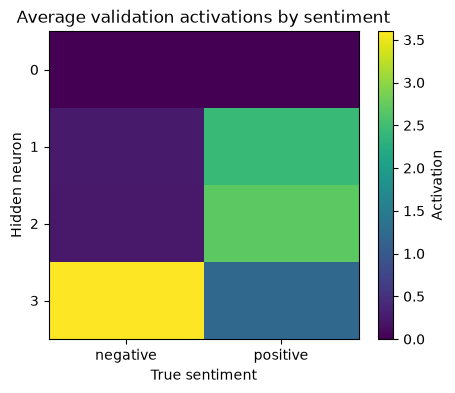

In [6]:
with torch.no_grad():
    _, val_hidden = model(X_val)
    avg_activations = torch.stack([
        val_hidden[y_val == label].mean(dim=0) for label in range(2)
    ])

plt.figure(figsize=(5, 4))
plt.imshow(avg_activations.T.numpy(), aspect="auto", cmap="viridis")
plt.xticks([0, 1], class_names)
plt.yticks(range(model.fc1.out_features))
plt.xlabel("True sentiment")
plt.ylabel("Hidden neuron")
plt.title("Average validation activations by sentiment")
plt.colorbar(label="Activation")
plt.show()


#### Reading the Activation Plot

Brighter cells indicate stronger average activation. Compare each neuron's
response to positive and negative sentences. A dark neuron may be inactive
on these inputs. With only six validation examples, these averages are limited;
activation differences alone do not prove that a neuron controls the prediction.


### Neuron Ablation (single neuron)

In [7]:
test_text = "This movie was great."
test_input = encode_texts([test_text])
neuron_to_zero = 3

model.eval()
with torch.no_grad():
    baseline_logits, hidden = model(test_input)
    baseline_probability = baseline_logits.softmax(dim=1)[0, 1].item()
    ablated_hidden = hidden.clone()
    ablated_hidden[:, neuron_to_zero] = 0
    modified_logits = model.fc2(ablated_hidden)
    modified_probability = modified_logits.softmax(dim=1)[0, 1].item()

print("Input:", test_text, "| Expected: positive")
print("Baseline prediction:", class_names[baseline_logits.argmax(dim=1).item()])
print("Ablated prediction:", class_names[modified_logits.argmax(dim=1).item()])
print(f"Positive probability: {baseline_probability:.4f} -> {modified_probability:.4f}")
print(f"Change after zeroing neuron {neuron_to_zero}: "
      f"{modified_probability - baseline_probability:+.4f}")


Input: This movie was great. | Expected: positive
Baseline prediction: positive
Ablated prediction: positive
Positive probability: 0.9998 -> 1.0000
Change after zeroing neuron 3: +0.0002


#### Reading the Ablation Result

Zeroing a hidden activation tests its contribution to this particular prediction.
A probability change can reveal an effect even when the predicted label stays the
same. No change on one input does not establish that the neuron is unused overall.


### Neuron Ablation (sweep of neurons)

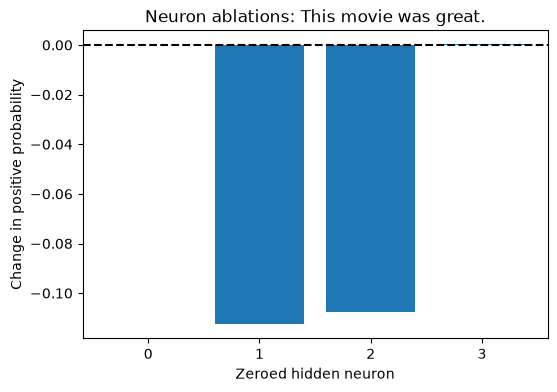

Neuron 0: change in positive probability +0.0000
Neuron 1: change in positive probability -0.1126
Neuron 2: change in positive probability -0.1077
Neuron 3: change in positive probability +0.0002


In [8]:
neuron_indices = list(range(model.fc1.out_features))
signed_deltas = []
with torch.no_grad():
    for index in neuron_indices:
        ablated_hidden = hidden.clone()
        ablated_hidden[:, index] = 0
        ablated_logits = model.fc2(ablated_hidden)
        probability = ablated_logits.softmax(dim=1)[0, 1].item()
        signed_deltas.append(probability - baseline_probability)

plt.figure(figsize=(6, 4))
plt.bar(neuron_indices, signed_deltas)
plt.axhline(0, color="black", linestyle="--")
plt.xticks(neuron_indices)
plt.xlabel("Zeroed hidden neuron")
plt.ylabel("Change in positive probability")
plt.title(f"Neuron ablations: {test_text}")
plt.show()
for index, delta in zip(neuron_indices, signed_deltas):
    print(f"Neuron {index}: change in positive probability {delta:+.4f}")


#### Reading the Ablation Sweep

A negative change means zeroing the neuron reduced positive probability; a positive
change means it increased positive probability. Compare magnitudes to see which
neurons affect this example most. Try other inputs before drawing general conclusions.
